# 🌊 Streaming Window Aggregator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/streaming-aggregator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/streaming-aggregator/demo.ipynb)

**Pain point:** *"We can't compute rolling metrics live."*

Event-time windowing with watermarks in ~100 lines: tumbling and sliding windows, out-of-order streams, and late events counted instead of silently lost — the same semantics Flink and Spark Structured Streaming implement at scale.

**What this notebook covers:**
1. The aggregator — event time vs arrival time, watermarks, finalization
2. Feeding an out-of-order stream through tumbling windows
3. Conservation check — every event windowed or counted late
4. Tumbling vs sliding, visualized
5. The lateness trade-off
6. Try your own windows


## Step 1 — The aggregator

The three ideas every streaming engine is built on:

- **Event time ≠ arrival time.** Events carry the timestamp of when they *happened*; the network delivers them out of order. Windows are computed on event time.
- **Watermark** = max event time seen minus `allowed_lateness`. It's the stream's claim: "nothing older than this is still coming."
- **Finalization.** A window is emitted (immutable, safe for dashboards) once the watermark passes its end. Events that arrive after their window closed are **counted as `late_dropped`** — an explicit metric, never a silent merge or a silent loss.

Tumbling = slide equals window (each event in exactly one window). Sliding = slide < window (each event in several overlapping windows).


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple


@dataclass
class Event:
    ts: float          # event time (epoch seconds) — when it happened, not when it arrived
    key: str
    value: float


@dataclass
class WindowResult:
    window_start: float
    window_end: float
    key: str
    count: int
    total: float
    vmin: float
    vmax: float

    @property
    def mean(self) -> float:
        return round(self.total / self.count, 3) if self.count else 0.0


@dataclass
class _Acc:
    count: int = 0
    total: float = 0.0
    vmin: float = float("inf")
    vmax: float = float("-inf")

    def add(self, v: float) -> None:
        self.count += 1
        self.total += v
        self.vmin = min(self.vmin, v)
        self.vmax = max(self.vmax, v)


class WindowAggregator:
    """Event-time windowing with watermarks — the core of every streaming engine, in one class.

    - Tumbling: slide == window (each event lands in exactly one window)
    - Sliding: slide < window (each event lands in window/slide overlapping windows)
    - Watermark: max event time seen minus allowed_lateness. A window is finalized
      (emitted, immutable) once the watermark passes its end. Events older than
      their finalized window are counted as late_dropped, never silently merged.
    """

    def __init__(self, window_seconds: float, slide_seconds: Optional[float] = None,
                 allowed_lateness_seconds: float = 0.0) -> None:
        self.window = float(window_seconds)
        self.slide = float(slide_seconds) if slide_seconds else float(window_seconds)
        if self.slide > self.window:
            raise ValueError("slide must be <= window (gaps would drop events)")
        self.lateness = float(allowed_lateness_seconds)
        self.max_event_ts = float("-inf")
        self.late_dropped = 0
        self._open: Dict[Tuple[float, str], _Acc] = {}  # (window_start, key) -> acc

    @property
    def watermark(self) -> float:
        return self.max_event_ts - self.lateness

    def _windows_for(self, ts: float) -> List[float]:
        first = (ts // self.slide) * self.slide
        starts = []
        start = first
        while start > ts - self.window:
            starts.append(start)
            start -= self.slide
        return [s for s in starts if s <= ts < s + self.window]

    def feed(self, event: Event) -> List[WindowResult]:
        """Add one event; return any windows finalized by the advancing watermark."""
        self.max_event_ts = max(self.max_event_ts, event.ts)
        placed = False
        for start in self._windows_for(event.ts):
            if start + self.window <= self.watermark:
                continue  # this window already closed — event is too late for it
            self._open.setdefault((start, event.key), _Acc()).add(event.value)
            placed = True
        if not placed:
            self.late_dropped += 1
        return self._finalize_ripe()

    def _finalize_ripe(self) -> List[WindowResult]:
        ripe = [(ws, key) for (ws, key) in self._open if ws + self.window <= self.watermark]
        out: List[WindowResult] = []
        for ws, key in sorted(ripe):
            acc = self._open.pop((ws, key))
            out.append(WindowResult(ws, ws + self.window, key, acc.count, round(acc.total, 3),
                                    acc.vmin, acc.vmax))
        return out

    def flush(self) -> List[WindowResult]:
        """End of stream: emit everything still open."""
        out = [WindowResult(ws, ws + self.window, key, acc.count, round(acc.total, 3),
                            acc.vmin, acc.vmax)
               for (ws, key), acc in sorted(self._open.items())]
        self._open.clear()
        return out


def make_event_stream(n: int = 2000, keys: Tuple[str, ...] = ("checkout", "search", "api"),
                      duration_s: float = 600.0, disorder_s: float = 8.0,
                      late_fraction: float = 0.02, late_by_s: float = 90.0,
                      seed: int = 7) -> List[Event]:
    """Out-of-order stream in *arrival* order: mild disorder plus a few very-late stragglers."""
    import random
    rng = random.Random(seed)
    events = []
    for i in range(n):
        true_ts = duration_s * i / n
        arrival_skew = rng.uniform(0, disorder_s)
        if rng.random() < late_fraction:
            arrival_skew += late_by_s
        events.append((true_ts + arrival_skew,  # arrival order key
                       Event(ts=round(true_ts, 2), key=rng.choice(keys),
                             value=round(rng.uniform(10, 200), 2))))
    events.sort(key=lambda p: p[0])
    return [e for _, e in events]


## Step 2 — Run an out-of-order stream

2,000 events over 10 simulated minutes, three keys, mild disorder (~8s) plus 2% very-late stragglers (+90s). Tumbling 60s windows, 10s allowed lateness. Windows finalize *while the stream flows* — that's the live part.

In [2]:
stream = make_event_stream(n=2000, duration_s=600, disorder_s=8.0,
                           late_fraction=0.02, late_by_s=90.0)

agg = WindowAggregator(window_seconds=60, allowed_lateness_seconds=10)
finalized = []
emitted_live = 0
for e in stream:
    out = agg.feed(e)
    emitted_live += len(out)
    finalized.extend(out)
tail = agg.flush()
finalized.extend(tail)

print(f"events fed:            {len(stream):,}")
print(f"windows emitted live:  {emitted_live} (while stream was flowing)")
print(f"windows at flush:      {len(tail)}")
print(f"late events dropped:   {agg.late_dropped}")
print()
for w in finalized[:6]:
    print(f"  [{w.window_start:5.0f} → {w.window_end:5.0f})  {w.key:9s} n={w.count:3d}  mean={w.mean:7.2f}")

events fed:            2,000
windows emitted live:  27 (while stream was flowing)
windows at flush:      3
late events dropped:   35

  [    0 →    60)  api       n= 49  mean=  98.24
  [    0 →    60)  checkout  n= 71  mean= 108.33
  [    0 →    60)  search    n= 77  mean= 110.80
  [   60 →   120)  api       n= 63  mean= 110.03
  [   60 →   120)  checkout  n= 74  mean=  96.06
  [   60 →   120)  search    n= 58  mean=  96.62


## Step 3 — Conservation check

A streaming aggregator you can trust accounts for every event: windowed or explicitly late, nothing vanishes.

In [3]:
windowed = sum(w.count for w in finalized)
assert windowed + agg.late_dropped == len(stream)
print(f"✅ {windowed:,} windowed + {agg.late_dropped} late = {len(stream):,} events — nothing lost")

✅ 1,965 windowed + 35 late = 2,000 events — nothing lost


## Step 4 — Tumbling vs sliding

Same stream, 60s windows — tumbling vs sliding with a 20s slide. Sliding gives 3x the points and a smoother curve, at 3x the state.

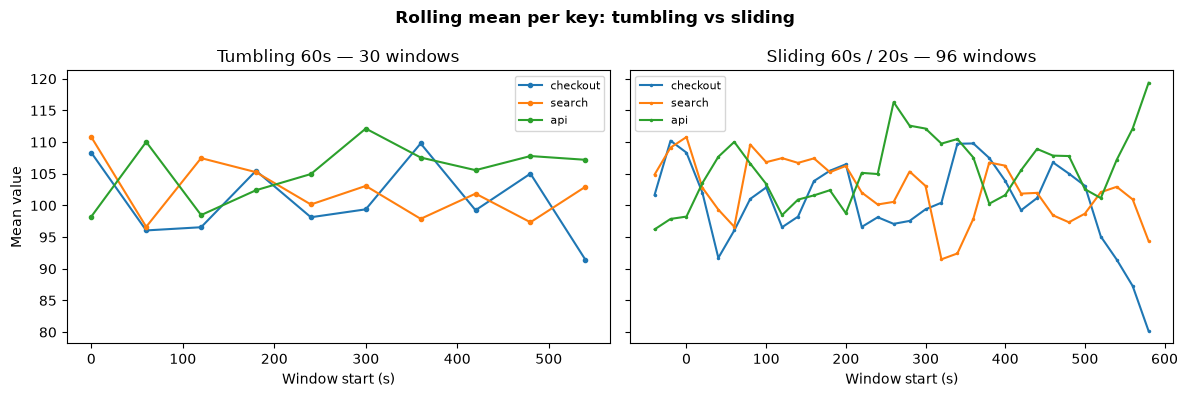

In [4]:
import matplotlib.pyplot as plt

agg_s = WindowAggregator(window_seconds=60, slide_seconds=20, allowed_lateness_seconds=10)
sliding = []
for e in stream:
    sliding.extend(agg_s.feed(e))
sliding.extend(agg_s.flush())

def series(results, key):
    pts = sorted((w.window_start, w.mean) for w in results if w.key == key)
    return [p[0] for p in pts], [p[1] for p in pts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for key in ("checkout", "search", "api"):
    ax1.plot(*series(finalized, key), marker="o", markersize=3, label=key)
    ax2.plot(*series(sliding, key), marker=".", markersize=3, label=key)
ax1.set_title(f"Tumbling 60s — {len(finalized)} windows")
ax2.set_title(f"Sliding 60s / 20s — {len(sliding)} windows")
for ax in (ax1, ax2):
    ax.set_xlabel("Window start (s)")
    ax.legend(fontsize=8)
ax1.set_ylabel("Mean value")
fig.suptitle("Rolling mean per key: tumbling vs sliding", fontweight="bold")
fig.tight_layout()
fig.savefig("windows_tumbling_vs_sliding.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — The lateness trade-off

`allowed_lateness` buys correctness with delay: bigger values absorb more stragglers (fewer drops) but hold windows open longer before dashboards can trust them.

In [5]:
for lateness in (0, 10, 30, 60, 120):
    a = WindowAggregator(60, allowed_lateness_seconds=lateness)
    for e in stream:
        a.feed(e)
    a.flush()
    print(f"lateness={lateness:4d}s → late_dropped={a.late_dropped:3d}")

lateness=   0s → late_dropped=116
lateness=  10s → late_dropped= 35
lateness=  30s → late_dropped= 35
lateness=  60s → late_dropped= 19
lateness= 120s → late_dropped=  0


## Summary

| Concept | This build | Flink / Spark equivalent |
|---|---|---|
| Event-time windows | `_windows_for(ts)` | `window(col, '60 seconds')` |
| Watermark | `max_event_ts - lateness` | `withWatermark()` |
| Finalization | emit when watermark passes window end | trigger + append mode |
| Late data | `late_dropped` counter | late data metrics / side output |

The whole streaming mental model in one file — and a conservation assertion most production pipelines never write.


## Try your own

In [6]:
# fast 5-minute dashboards over 1-second ticks:
# a = WindowAggregator(window_seconds=300, slide_seconds=60, allowed_lateness_seconds=30)
# for e in my_events:                     # Event(ts=..., key=..., value=...)
#     for w in a.feed(e):
#         print(f"[{w.window_start} → {w.window_end}) {w.key}: mean={w.mean}")
# print("late:", a.late_dropped)

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
